# Análise Exploratória dos dados

Objetivo: Análise exploratória dos dados anterior a modelagem.
1) Avaliar a distribuição dos dados.
2) Avaliar a qualidade dos dados.
3) Procurar por possíveis correlações.
4) Identificar quaisquer fatores que possam influenciar a próxima etapa.


## 1) Carregamento das bibliotecas

In [2]:
from pathlib import Path
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path(".")

from src.config import PROCESSED_DATA_DIR
from src.preprocessing.io import read_parquet

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

2026-09-07 22:37:42.198 | INFO     | src.config:<module>:11 - PROJ_ROOT path is: /home/mburger/study/postech/techchallenge3/postech-challenge-3


## 2) Carregamento dos dados

In [3]:
df = read_parquet(PROCESSED_DATA_DIR / 'base_analitica')

# Metadado técnico do pipeline: não será usado na análise.
if '_gold_processed_at' in df.columns:
    df = df.drop(columns='_gold_processed_at')

print(f'Tamanho da base (linhas, colunas): {df.shape}')
print(f'Anos disponíveis: {sorted(df.ano.dropna().unique())}')
df.head()

Tamanho da base (linhas, colunas): (5320732, 49)
Anos disponíveis: [np.int64(2023), np.int64(2024), np.int64(2025)]


,ano,id_uf,id_municipio,id_escola,id_aluno,dependencia_administrativa,label_proficiencia,label_alfabetizado,ctx_atu_educacao_infantil,ctx_atu_creche,ctx_atu_pre_escola,ctx_atu_fundamental,ctx_atu_fundamental_anos_iniciais,ctx_atu_fundamental_anos_finais,ctx_atu_fundamental_1_ano,ctx_atu_fundamental_2_ano,ctx_atu_fundamental_3_ano,ctx_atu_fundamental_4_ano,ctx_atu_fundamental_5_ano,ctx_atu_fundamental_6_ano,ctx_atu_fundamental_7_ano,ctx_atu_fundamental_8_ano,ctx_atu_fundamental_9_ano,ctx_atu_multietapa,ctx_atu_medio,ctx_atu_medio_1_serie,ctx_atu_medio_2_serie,ctx_atu_medio_3_serie,ctx_atu_medio_4_serie,ctx_atu_medio_nao_seriado,ctx_fundeb_nse_municipio,ctx_fundeb_ponderador_nse_municipio,ctx_fundeb_nse_uf,ctx_fundeb_ponderador_nse_uf,ctx_ibge_populacao_residente,ctx_ibge_area_km2,ctx_ibge_pct_populacao_rural,ctx_ibge_pct_esgoto_adequado,ctx_ibge_renda_domiciliar_per_capita_mediana,ctx_ibge_renda_domiciliar_per_capita_media,ctx_inep_mun_taxa_alfabetizacao_lag1,ctx_inep_mun_media_portugues_lag1,ctx_inep_mun_percentual_participacao_lag1,ctx_inep_mun_nivel_alfabetizacao_lag1,ctx_inep_mun_meta,ctx_inep_uf_taxa_alfabetizacao_lag1,ctx_inep_uf_media_portugues_lag1,ctx_inep_uf_percentual_participacao_lag1,ctx_inep_uf_meta
0,2023,11,1100205,60000001,11008695,3,714.314857,0,19.1,17.5,19.7,21.1,21.4,20.6,20.4,21.6,21.6,21.4,22.3,23.8,22.0,18.8,17.9,13.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,34090.952,0.074137,0.230274,866.67,1459.81,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,<NA>
1,2023,11,1100205,60000001,11008682,3,759.206313,1,19.1,17.5,19.7,21.1,21.4,20.6,20.4,21.6,21.6,21.4,22.3,23.8,22.0,18.8,17.9,13.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,34090.952,0.074137,0.230274,866.67,1459.81,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,<NA>
2,2023,11,1100205,60000001,11008665,3,796.026914,1,19.1,17.5,19.7,21.1,21.4,20.6,20.4,21.6,21.6,21.4,22.3,23.8,22.0,18.8,17.9,13.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,34090.952,0.074137,0.230274,866.67,1459.81,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,<NA>
3,2023,11,1100205,60000001,11008730,3,754.646186,1,19.1,17.5,19.7,21.1,21.4,20.6,20.4,21.6,21.6,21.4,22.3,23.8,22.0,18.8,17.9,13.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,34090.952,0.074137,0.230274,866.67,1459.81,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,<NA>
4,2023,11,1100205,60000001,11008667,3,796.026914,1,19.1,17.5,19.7,21.1,21.4,20.6,20.4,21.6,21.6,21.4,22.3,23.8,22.0,18.8,17.9,13.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,34090.952,0.074137,0.230274,866.67,1459.81,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,<NA>


In [4]:
alvo = alvo_classificacao = 'label_alfabetizado'
#alvo_regressao = 'label_proficiencia'

# Colunas de contexto criadas no pipeline.
variaveis_contexto = [col for col in df.columns if col.startswith('ctx_')]

print('Quantidade de variáveis de contexto:', len(variaveis_contexto))

Quantidade de variáveis de contexto: 41


In [5]:
# Carrega dicionário id_uf -> sigla_uf da tabela de populacao_municipios nos dados processados
df_popul = read_parquet(PROCESSED_DATA_DIR / "populacao_municipios")
dict_uf_sigla = df_popul.drop_duplicates(subset=['id_uf', 'sigla_uf']).set_index('id_uf')['sigla_uf'].to_dict()
df['sigla_uf'] = df['id_uf'].map(dict_uf_sigla)

## Análise dos dados

Tipos dos dados:

In [6]:
df.dtypes

ano                                               Int64
id_uf                                             Int64
id_municipio                                     string
id_escola                                        string
id_aluno                                         string
dependencia_administrativa                        Int64
label_proficiencia                              float64
label_alfabetizado                                Int64
ctx_atu_educacao_infantil                       float64
ctx_atu_creche                                  float64
ctx_atu_pre_escola                              float64
ctx_atu_fundamental                             float64
ctx_atu_fundamental_anos_iniciais               float64
ctx_atu_fundamental_anos_finais                 float64
ctx_atu_fundamental_1_ano                       float64
ctx_atu_fundamental_2_ano                       float64
ctx_atu_fundamental_3_ano                       float64
ctx_atu_fundamental_4_ano                       

Estatísticas básicas do dataset:

In [7]:
df.describe().round(2)

,ano,id_uf,dependencia_administrativa,label_proficiencia,label_alfabetizado,ctx_atu_educacao_infantil,ctx_atu_creche,ctx_atu_pre_escola,ctx_atu_fundamental,ctx_atu_fundamental_anos_iniciais,ctx_atu_fundamental_anos_finais,ctx_atu_fundamental_1_ano,ctx_atu_fundamental_2_ano,ctx_atu_fundamental_3_ano,ctx_atu_fundamental_4_ano,ctx_atu_fundamental_5_ano,ctx_atu_fundamental_6_ano,ctx_atu_fundamental_7_ano,ctx_atu_fundamental_8_ano,ctx_atu_fundamental_9_ano,ctx_atu_multietapa,ctx_atu_medio,ctx_atu_medio_1_serie,ctx_atu_medio_2_serie,ctx_atu_medio_3_serie,ctx_atu_medio_4_serie,ctx_atu_medio_nao_seriado,ctx_fundeb_nse_municipio,ctx_fundeb_ponderador_nse_municipio,ctx_fundeb_nse_uf,ctx_fundeb_ponderador_nse_uf,ctx_ibge_populacao_residente,ctx_ibge_area_km2,ctx_ibge_pct_populacao_rural,ctx_ibge_pct_esgoto_adequado,ctx_ibge_renda_domiciliar_per_capita_mediana,ctx_ibge_renda_domiciliar_per_capita_media,ctx_inep_mun_taxa_alfabetizacao_lag1,ctx_inep_mun_media_portugues_lag1,ctx_inep_mun_percentual_participacao_lag1,ctx_inep_mun_nivel_alfabetizacao_lag1,ctx_inep_mun_meta,ctx_inep_uf_taxa_alfabetizacao_lag1,ctx_inep_uf_media_portugues_lag1,ctx_inep_uf_percentual_participacao_lag1,ctx_inep_uf_meta
count,5320732.0,5320732.0,5320732.0,5320732.00,5320732.0,4944325.00,4884683.00,4933724.00,5320732.00,5320588.00,4439624.00,5308190.00,5320053.00,5319537.00,5318955.00,5319143.00,4436453.00,4403015.00,4387610.00,4378240.00,3459834.00,894293.00,884518.00,884813.00,886447.00,218770.00,213072.00,3771821.00,3771821.00,3817923.00,3817923.00,3817923.0,5320622.0,5320622.0,5320622.0,5320622.0,5320622.0,3739029.00,3739029.00,3673765.00,3673765.0,3766136.00,3752471.00,3752471.00,3752471.00,3785578.0
mean,2024.09,32.1,2.88,750.30,0.62,17.57,16.33,18.84,23.57,22.80,26.45,21.28,22.24,23.07,23.83,23.99,26.60,26.81,26.48,25.92,14.98,27.77,29.65,27.50,26.74,18.77,11.60,50.93,1.00,50.81,1.00,1077762.26,2591.68,0.15,0.57,1001.93,1528.57,57.00,745.92,87.57,2.2,60.35,57.82,746.91,87.24,62.01
std,0.8,10.21,0.32,47.81,0.49,3.63,4.56,3.47,4.21,3.78,5.37,3.70,3.76,4.00,4.20,4.37,5.32,5.56,5.68,5.83,5.11,5.71,5.89,6.18,5.84,7.60,7.87,7.03,0.02,6.52,0.02,2718037.74,8180.49,0.18,0.33,363.51,662.03,16.00,20.06,6.17,1.49,12.80,11.36,14.60,5.12,8.09
min,2023.0,11.0,2.0,572.36,0.0,1.00,1.40,1.00,1.60,1.80,1.00,1.00,2.00,1.00,2.00,1.00,1.00,1.00,1.00,1.00,1.50,3.30,2.00,2.00,2.00,1.00,1.00,30.76,0.95,39.37,0.97,854.0,3.56,0.0,0.0,160.0,288.65,4.35,673.30,70.00,0.0,0.00,31.30,713.13,70.05,38.0
25%,2023.0,26.0,3.0,722.69,0.0,15.60,13.70,17.00,20.70,20.30,23.10,19.00,19.90,20.40,21.00,20.90,23.40,23.30,22.90,22.30,11.60,24.80,27.50,24.30,23.60,15.00,9.00,44.75,0.98,44.17,0.98,30556.0,308.11,0.01,0.27,686.0,1004.63,46.04,733.58,83.45,1.0,52.00,51.91,738.90,84.53,57.0
50%,2024.0,32.0,3.0,756.15,1.0,17.70,16.30,18.80,23.70,22.90,27.10,21.20,22.20,23.10,23.90,24.20,27.20,27.50,27.10,26.70,14.50,28.30,30.40,28.70,27.50,19.00,10.40,52.22,1.00,52.18,1.00,117759.0,700.59,0.06,0.65,1000.0,1450.2,56.12,743.62,87.67,2.0,61.00,58.13,747.39,88.75,61.0
75%,2025.0,41.0,3.0,782.01,1.0,19.80,18.90,21.00,26.40,25.40,30.40,23.60,24.60,25.90,27.00,27.40,30.60,30.90,30.50,30.00,17.80,32.20,33.90,32.20,31.30,21.00,10.70,56.46,1.01,57.46,1.02,501597.0,1623.44,0.23,0.89,1250.0,1902.87,67.79,755.12,92.00,3.0,69.00,63.43,752.15,89.59,66.0
max,2025.0,53.0,3.0,904.38,1.0,69.40,82.00,64.30,36.90,33.60,46.10,35.70,36.00,41.00,39.00,42.00,51.80,49.50,47.50,47.30,59.00,46.00,47.40,52.30,50.50,79.00,95.00,69.99,1.05,60.72,1.03,11904961.0,159533.31,0.93,1.0,2500.0,4299.91,100.00,868.46,100.00,5.0,80.00,85.31,797.29,98.13,80.0


Contagem de linhas por ano:

ano
2025    1966095
2024    1851828
2023    1502809
Name: count, dtype: Int64


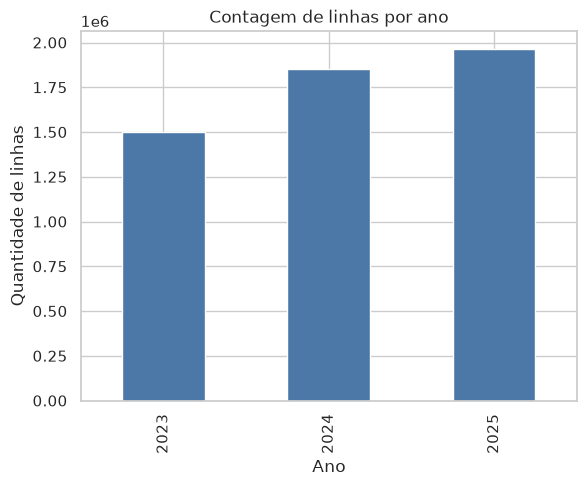

In [8]:
print(df.ano.value_counts())
df_ano_counts = df.ano.value_counts().sort_index()
df_ano_counts.plot(kind='bar', color='#4C78A8')
plt.title('Contagem de linhas por ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade de linhas')
plt.show()



Avaliação da variável alvo:

label_alfabetizado
0    2033517
1    3287215
Name: count, dtype: Int64
label_alfabetizado
0    0.382187
1    0.617813
Name: proportion, dtype: Float64


Text(0, 0.5, 'Quantidade de alunos')

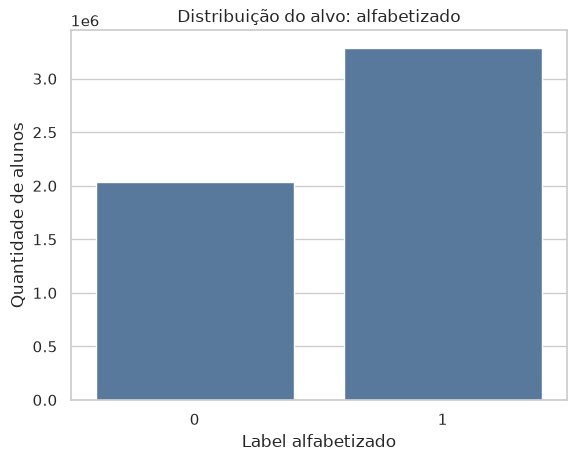

In [9]:
print(df[alvo_classificacao].value_counts(dropna=False).sort_index())
print(df[alvo_classificacao].value_counts(normalize=True, dropna=False).sort_index())

sns.countplot(data=df, x=alvo_classificacao, color='#4C78A8')
plt.title('Distribuição do alvo: alfabetizado')
plt.xlabel('Label alfabetizado')
plt.ylabel('Quantidade de alunos')

Frequência absoluta da variável alvo por ano:


label_alfabetizado,0,1
ano,,
2023,625382,877427
2024,744725,1107103
2025,663410,1302685


Frequência relativa da variável alvo por ano:


label_alfabetizado,0,1
ano,,
2023,0.416,0.584
2024,0.402,0.598
2025,0.337,0.663


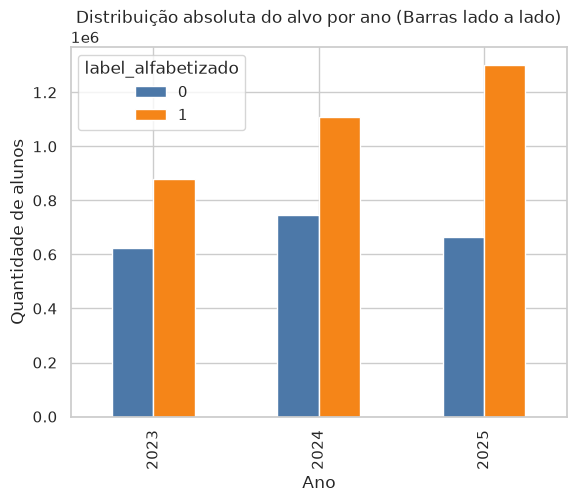

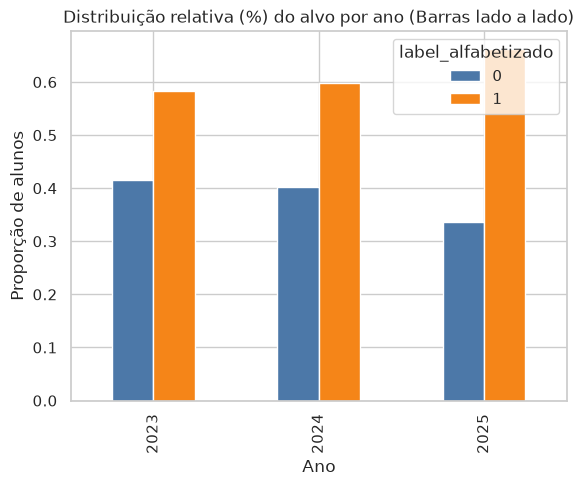

In [10]:
# Distribuição da variável alvo por ano (barras lado a lado - side-by-side, não empilhadas)

# Calcula frequência absoluta e relativa por ano
dist_ano_abs = df.groupby("ano")[alvo_classificacao].value_counts(dropna=False).unstack().fillna(0).astype(int)
dist_ano_rel = df.groupby("ano")[alvo_classificacao].value_counts(normalize=True, dropna=False).unstack().fillna(0).round(3)

print("Frequência absoluta da variável alvo por ano:")
display(dist_ano_abs)

print("Frequência relativa da variável alvo por ano:")
display(dist_ano_rel)

# Gráfico de barras lado a lado para a distribuição absoluta
fig, ax = plt.subplots()
dist_ano_abs.plot(kind='bar', stacked=False, color=["#4C78A8", "#F58518"], ax=ax)
ax.set_title('Distribuição absoluta do alvo por ano (Barras lado a lado)')
ax.set_xlabel('Ano')
ax.set_ylabel('Quantidade de alunos')
ax.legend(title=alvo_classificacao)
plt.show()

# Gráfico de barras lado a lado para a distribuição relativa
fig, ax = plt.subplots()
dist_ano_rel.plot(kind='bar', stacked=False, color=["#4C78A8", "#F58518"], ax=ax)
ax.set_title('Distribuição relativa (%) do alvo por ano (Barras lado a lado)')
ax.set_xlabel('Ano')
ax.set_ylabel('Proporção de alunos')
ax.legend(title=alvo_classificacao)
plt.show()

### Alunos por turma

In [11]:
colunas_atu = [
    'ctx_atu_educacao_infantil',
    'ctx_atu_creche',
    'ctx_atu_pre_escola',
    'ctx_atu_fundamental_anos_iniciais',
    'ctx_atu_fundamental_1_ano',
    'ctx_atu_fundamental_2_ano',
]

display(df[colunas_atu].describe().round(2))
print("\nNulos: \n", df[colunas_atu].isnull().sum(), sep='')
print("\nProporção de nulos (%): \n", (df[colunas_atu].isnull().mean() * 100).round(2), sep='')
print("\nÚnicos: \n", df[colunas_atu].nunique(), sep='')


,ctx_atu_educacao_infantil,ctx_atu_creche,ctx_atu_pre_escola,ctx_atu_fundamental_anos_iniciais,ctx_atu_fundamental_1_ano,ctx_atu_fundamental_2_ano
count,4944325.00,4884683.00,4933724.00,5320588.00,5308190.00,5320053.00
mean,17.57,16.33,18.84,22.80,21.28,22.24
std,3.63,4.56,3.47,3.78,3.70,3.76
min,1.00,1.40,1.00,1.80,1.00,2.00
25%,15.60,13.70,17.00,20.30,19.00,19.90
50%,17.70,16.30,18.80,22.90,21.20,22.20
75%,19.80,18.90,21.00,25.40,23.60,24.60
max,69.40,82.00,64.30,33.60,35.70,36.00



Nulos: 
ctx_atu_educacao_infantil            376407
ctx_atu_creche                       436049
ctx_atu_pre_escola                   387008
ctx_atu_fundamental_anos_iniciais       144
ctx_atu_fundamental_1_ano             12542
ctx_atu_fundamental_2_ano               679
dtype: int64

Proporção de nulos (%): 
ctx_atu_educacao_infantil            7.07
ctx_atu_creche                       8.20
ctx_atu_pre_escola                   7.27
ctx_atu_fundamental_anos_iniciais    0.00
ctx_atu_fundamental_1_ano            0.24
ctx_atu_fundamental_2_ano            0.01
dtype: float64

Únicos: 
ctx_atu_educacao_infantil            270
ctx_atu_creche                       345
ctx_atu_pre_escola                   265
ctx_atu_fundamental_anos_iniciais    281
ctx_atu_fundamental_1_ano            273
ctx_atu_fundamental_2_ano            283
dtype: int64


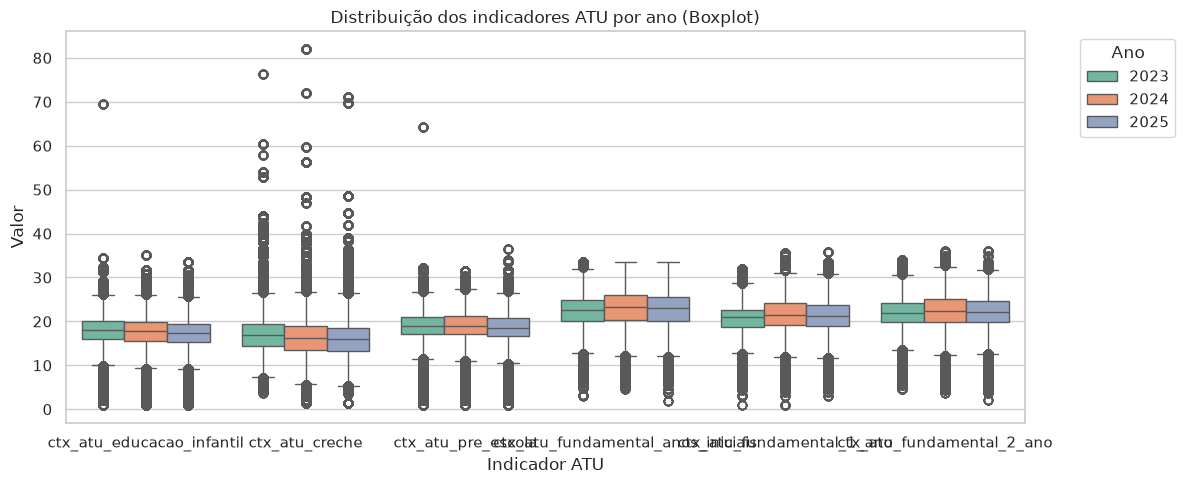

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparando os dados no formato "long" adequado para categorização no eixo x
df_boxplot = df.melt(
    id_vars=['ano'], 
    value_vars=colunas_atu,
    var_name='Indicador ATU', 
    value_name='Valor'
)

# Ordenando explicitamente os anos
anos_ordem = [2023, 2024, 2025]
df_boxplot = df_boxplot[df_boxplot['ano'].isin(anos_ordem)]
df_boxplot['ano'] = pd.Categorical(df_boxplot['ano'], categories=anos_ordem, ordered=True)

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=df_boxplot, 
    x="Indicador ATU", 
    y="Valor", 
    hue="ano", 
    palette="Set2"
)

plt.title("Distribuição dos indicadores ATU por ano (Boxplot)")
plt.xlabel("Indicador ATU")
plt.ylabel("Valor")
plt.legend(title="Ano", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

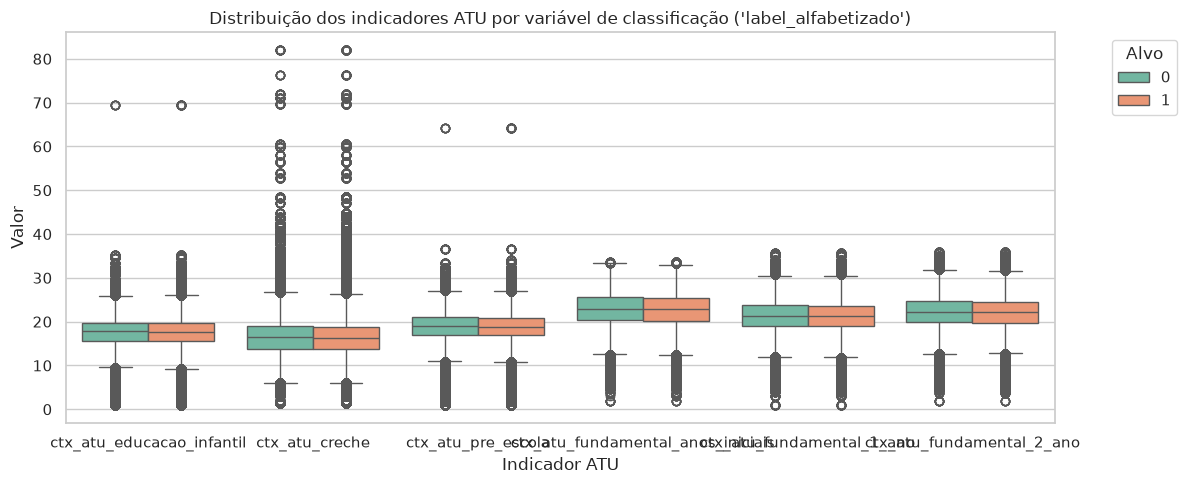

In [13]:
# Boxplot dos indicadores ATU por 'label_alfabetizado' (variável de classificação)

# O alvo sempre foi classificação (label_alfabetizado: 0 = não alfabetizado, 1 = alfabetizado)
df_boxplot_target = df.copy().dropna(subset=['label_alfabetizado'])

alvo = 'label_alfabetizado'

df_boxplot_label = df_boxplot_target.melt(
    id_vars=[alvo],
    value_vars=colunas_atu,
    var_name='Indicador ATU',
    value_name='Valor'
)

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=df_boxplot_label,
    x="Indicador ATU",
    y="Valor",
    hue=alvo,
    palette="Set2"
)
plt.title("Distribuição dos indicadores ATU por variável de classificação ('label_alfabetizado')")
plt.xlabel("Indicador ATU")
plt.ylabel("Valor")
plt.legend(title="Alvo", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
from scipy.stats import mannwhitneyu, ttest_ind

# Vamos aplicar os testes de Mann-Whitney-Wilcoxon (mannwhitneyu) e t (ttest_ind) para cada variável ATU, separando por ano.
resultados = []

for col in colunas_atu:
    for ano in sorted(df['ano'].dropna().unique()):
        grupo_1 = df[(df['ano'] == ano) & (df['label_alfabetizado'] == 0)][col].dropna()
        grupo_2 = df[(df['ano'] == ano) & (df['label_alfabetizado'] == 1)][col].dropna()
        
        # Mann-Whitney U test
        stat_mw, p_mw = mannwhitneyu(grupo_1, grupo_2, alternative='two-sided')
        
        # t-test
        # Usando equal_var=False devido à alta chance de variâncias diferentes
        stat_t, p_t = ttest_ind(grupo_1, grupo_2, equal_var=False, nan_policy='omit')
        
        # Médias
        media_0 = grupo_1.mean()
        media_1 = grupo_2.mean()
        
        resultados.append({
            'Indicador ATU': col,
            'Ano': ano,
            'n_alfabetizado=0': len(grupo_1),
            'n_alfabetizado=1': len(grupo_2),
            'Média grupo 0': media_0,
            'Média grupo 1': media_1,
            'Diferença absoluta': media_0 - media_1,
            'Estatística Mann-Whitney': stat_mw,
            'p-valor Mann-Whitney': p_mw,
            'Estatística t': stat_t,
            'p-valor t': p_t
        })

df_resultados = pd.DataFrame(resultados)
pd.set_option('display.max_rows', None)
display(df_resultados[df_resultados['Diferença absoluta'] > 1])

,Indicador ATU,Ano,n_alfabetizado=0,n_alfabetizado=1,Média grupo 0,Média grupo 1,Diferença absoluta,Estatística Mann-Whitney,p-valor Mann-Whitney,Estatística t,p-valor t


### IBGE

In [15]:
# Selecionar variáveis do IBGE pelo padrão do nome das colunas

# Vamos selecionar colunas cujo nome começa com 'ctx_ibge_'
colunas_ibge = [col for col in df.columns if col.startswith('ctx_ibge_')]
print("Variáveis do IBGE:")
print(colunas_ibge)

Variáveis do IBGE:
['ctx_ibge_populacao_residente', 'ctx_ibge_area_km2', 'ctx_ibge_pct_populacao_rural', 'ctx_ibge_pct_esgoto_adequado', 'ctx_ibge_renda_domiciliar_per_capita_mediana', 'ctx_ibge_renda_domiciliar_per_capita_media']


Distribuição, missing e relação das variáveis IBGE com `label_alfabetizado`.

In [16]:
display(df[colunas_ibge].describe().round(2))
print("\nNulos:\n", df[colunas_ibge].isnull().sum(), sep="")
print("\nProporção de nulos (%):\n", (df[colunas_ibge].isnull().mean() * 100).round(2), sep="")

print("\nNulos de ctx_ibge_populacao_residente por ano:")
print(
    df.groupby("ano")["ctx_ibge_populacao_residente"]
    .apply(lambda s: (s.isnull().mean() * 100).round(2))
    .rename("% nulos")
)

,ctx_ibge_populacao_residente,ctx_ibge_area_km2,ctx_ibge_pct_populacao_rural,ctx_ibge_pct_esgoto_adequado,ctx_ibge_renda_domiciliar_per_capita_mediana,ctx_ibge_renda_domiciliar_per_capita_media
count,3817923.0,5320622.0,5320622.0,5320622.0,5320622.0,5320622.0
mean,1077762.26,2591.68,0.15,0.57,1001.93,1528.57
std,2718037.74,8180.49,0.18,0.33,363.51,662.03
min,854.0,3.56,0.0,0.0,160.0,288.65
25%,30556.0,308.11,0.01,0.27,686.0,1004.63
50%,117759.0,700.59,0.06,0.65,1000.0,1450.2
75%,501597.0,1623.44,0.23,0.89,1250.0,1902.87
max,11904961.0,159533.31,0.93,1.0,2500.0,4299.91



Nulos:
ctx_ibge_populacao_residente                    1502809
ctx_ibge_area_km2                                   110
ctx_ibge_pct_populacao_rural                        110
ctx_ibge_pct_esgoto_adequado                        110
ctx_ibge_renda_domiciliar_per_capita_mediana        110
ctx_ibge_renda_domiciliar_per_capita_media          110
dtype: int64

Proporção de nulos (%):
ctx_ibge_populacao_residente                    28.24
ctx_ibge_area_km2                                0.00
ctx_ibge_pct_populacao_rural                     0.00
ctx_ibge_pct_esgoto_adequado                     0.00
ctx_ibge_renda_domiciliar_per_capita_mediana     0.00
ctx_ibge_renda_domiciliar_per_capita_media       0.00
dtype: float64

Nulos de ctx_ibge_populacao_residente por ano:
ano
2023    100.0
2024      0.0
2025      0.0
Name: % nulos, dtype: float64


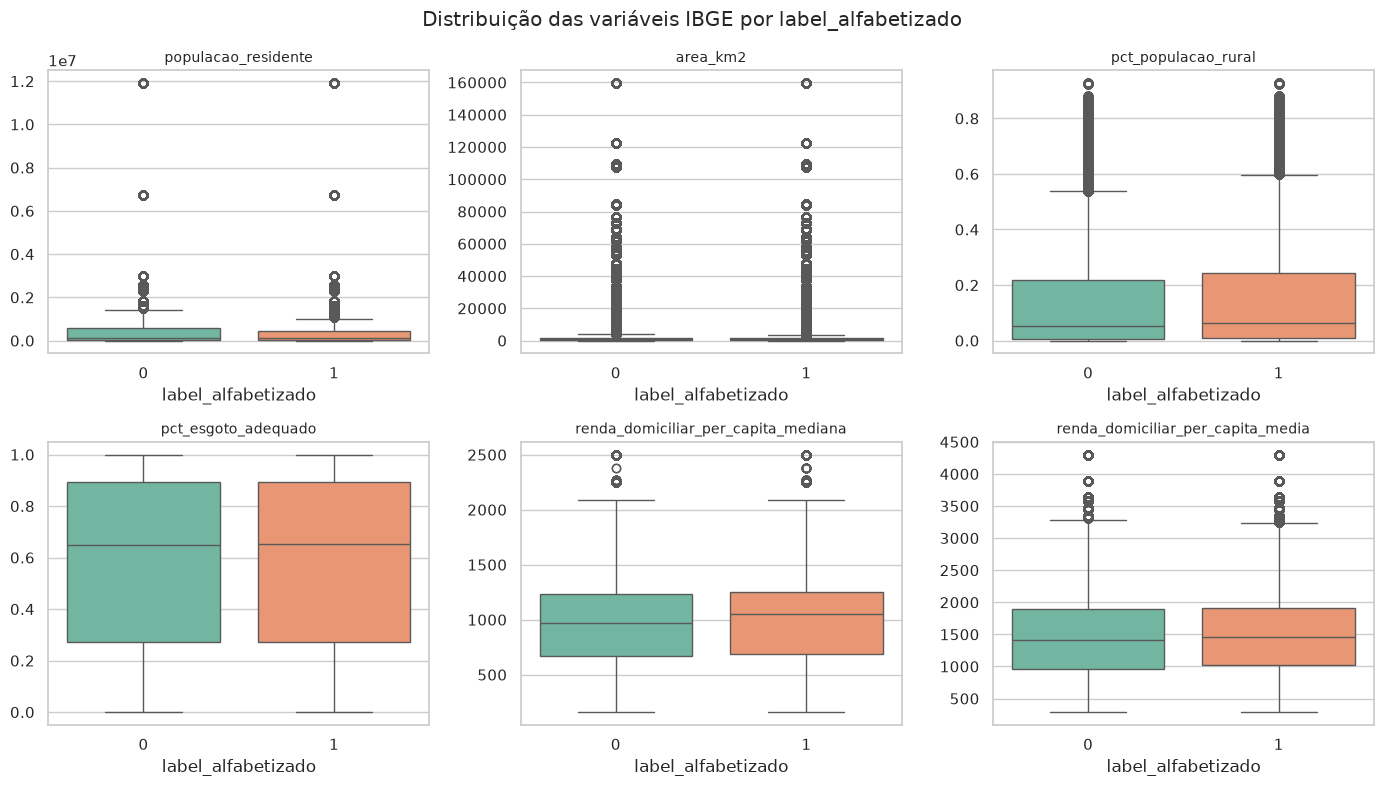

In [17]:
alvo = "label_alfabetizado"
df_plot = df.dropna(subset=[alvo])

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, col in zip(axes, colunas_ibge):
    sns.boxplot(data=df_plot, x=alvo, y=col, ax=ax, palette="Set2")
    ax.set_title(col.removeprefix("ctx_ibge_"), fontsize=10)
    ax.set_xlabel(alvo)
    ax.set_ylabel("")

fig.suptitle("Distribuição das variáveis IBGE por label_alfabetizado")
plt.tight_layout()
plt.show()

### INEP

In [18]:
# Selecionar variáveis do INEP pelo padrão do nome das colunas
colunas_inep = [col for col in df.columns if col.startswith("ctx_inep_")]
print("Variáveis do INEP:")
print(colunas_inep)

Variáveis do INEP:
['ctx_inep_mun_taxa_alfabetizacao_lag1', 'ctx_inep_mun_media_portugues_lag1', 'ctx_inep_mun_percentual_participacao_lag1', 'ctx_inep_mun_nivel_alfabetizacao_lag1', 'ctx_inep_mun_meta', 'ctx_inep_uf_taxa_alfabetizacao_lag1', 'ctx_inep_uf_media_portugues_lag1', 'ctx_inep_uf_percentual_participacao_lag1', 'ctx_inep_uf_meta']


Distribuição, missing e relação das variáveis INEP com `label_alfabetizado`.

In [19]:
display(df[colunas_inep].describe().round(2))
print("\nNulos:\n", df[colunas_inep].isnull().sum(), sep="")
print("\nProporção de nulos (%):\n", (df[colunas_inep].isnull().mean() * 100).round(2), sep="")

print("\nNulos de ctx_inep_mun_taxa_alfabetizacao_lag1 por ano:")
print(
    df.groupby("ano")["ctx_inep_mun_taxa_alfabetizacao_lag1"]
    .apply(lambda s: (s.isnull().mean() * 100).round(2))
    .rename("% nulos")
)

,ctx_inep_mun_taxa_alfabetizacao_lag1,ctx_inep_mun_media_portugues_lag1,ctx_inep_mun_percentual_participacao_lag1,ctx_inep_mun_nivel_alfabetizacao_lag1,ctx_inep_mun_meta,ctx_inep_uf_taxa_alfabetizacao_lag1,ctx_inep_uf_media_portugues_lag1,ctx_inep_uf_percentual_participacao_lag1,ctx_inep_uf_meta
count,3739029.00,3739029.00,3673765.00,3673765.0,3766136.00,3752471.00,3752471.00,3752471.00,3785578.0
mean,57.00,745.92,87.57,2.2,60.35,57.82,746.91,87.24,62.01
std,16.00,20.06,6.17,1.49,12.80,11.36,14.60,5.12,8.09
min,4.35,673.30,70.00,0.0,0.00,31.30,713.13,70.05,38.0
25%,46.04,733.58,83.45,1.0,52.00,51.91,738.90,84.53,57.0
50%,56.12,743.62,87.67,2.0,61.00,58.13,747.39,88.75,61.0
75%,67.79,755.12,92.00,3.0,69.00,63.43,752.15,89.59,66.0
max,100.00,868.46,100.00,5.0,80.00,85.31,797.29,98.13,80.0



Nulos:
ctx_inep_mun_taxa_alfabetizacao_lag1         1581703
ctx_inep_mun_media_portugues_lag1            1581703
ctx_inep_mun_percentual_participacao_lag1    1646967
ctx_inep_mun_nivel_alfabetizacao_lag1        1646967
ctx_inep_mun_meta                            1554596
ctx_inep_uf_taxa_alfabetizacao_lag1          1568261
ctx_inep_uf_media_portugues_lag1             1568261
ctx_inep_uf_percentual_participacao_lag1     1568261
ctx_inep_uf_meta                             1535154
dtype: int64

Proporção de nulos (%):
ctx_inep_mun_taxa_alfabetizacao_lag1         29.73
ctx_inep_mun_media_portugues_lag1            29.73
ctx_inep_mun_percentual_participacao_lag1    30.95
ctx_inep_mun_nivel_alfabetizacao_lag1        30.95
ctx_inep_mun_meta                            29.22
ctx_inep_uf_taxa_alfabetizacao_lag1          29.47
ctx_inep_uf_media_portugues_lag1             29.47
ctx_inep_uf_percentual_participacao_lag1     29.47
ctx_inep_uf_meta                             28.85
dtype: float64

Nu

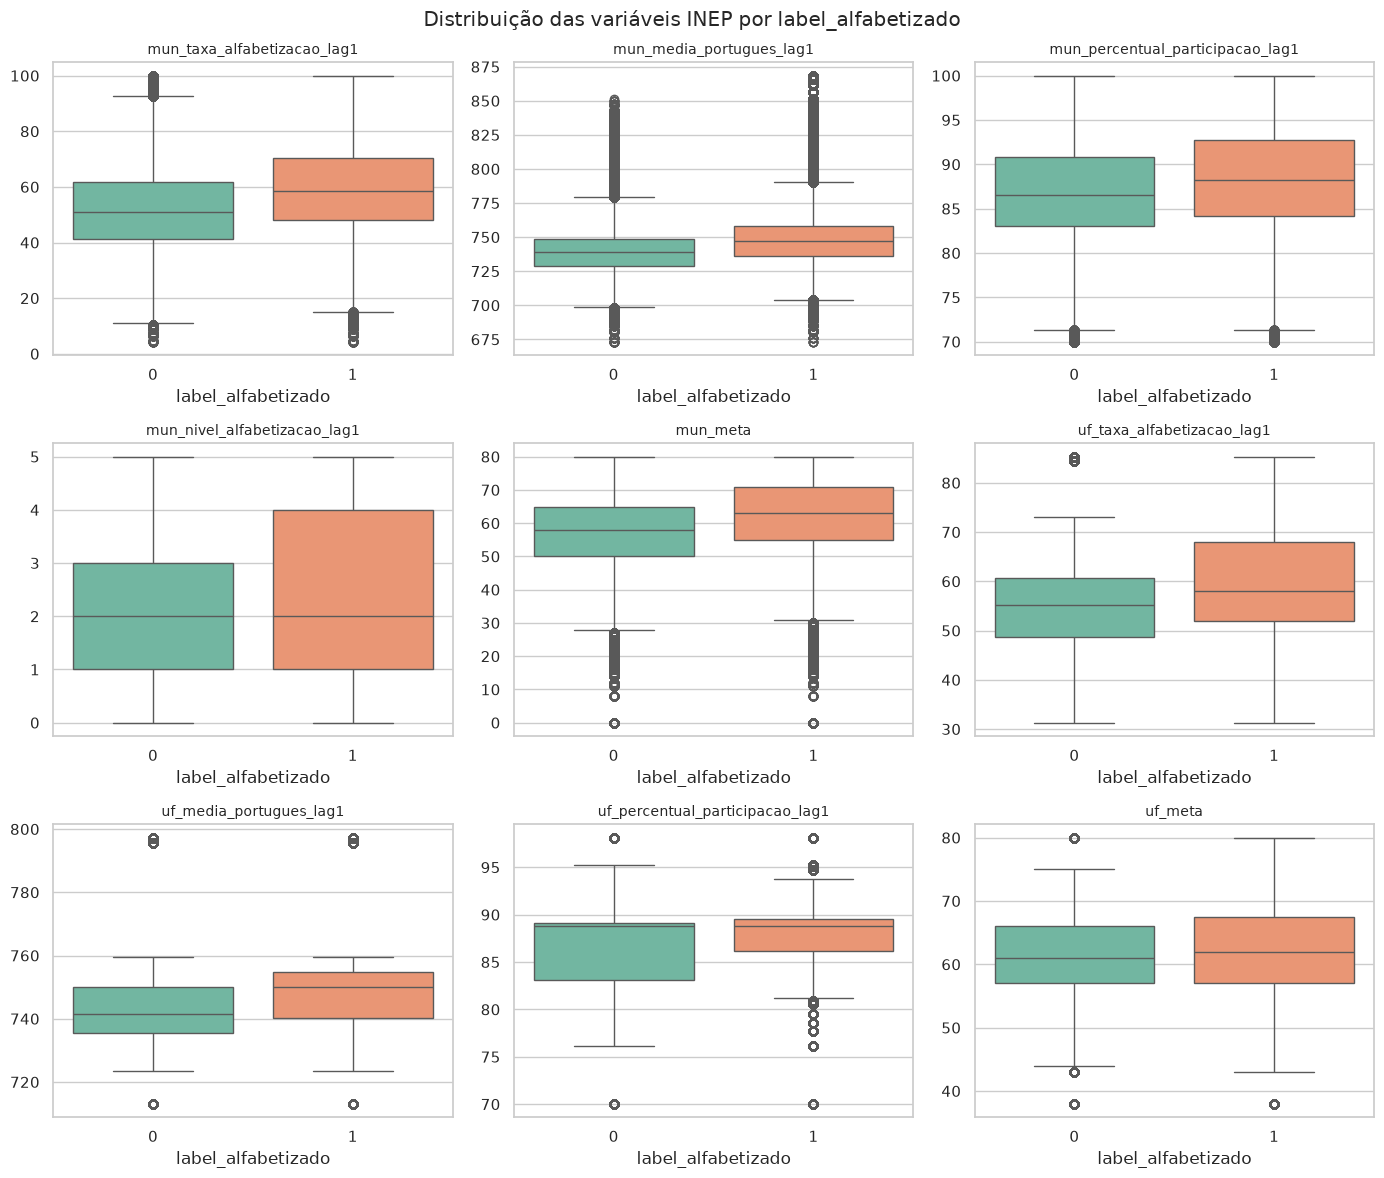

In [20]:
alvo = "label_alfabetizado"
df_plot = df.dropna(subset=[alvo])

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.ravel()

for ax, col in zip(axes, colunas_inep):
    sns.boxplot(data=df_plot, x=alvo, y=col, ax=ax, palette="Set2")
    ax.set_title(col.removeprefix("ctx_inep_"), fontsize=10)
    ax.set_xlabel(alvo)
    ax.set_ylabel("")

fig.suptitle("Distribuição das variáveis INEP por label_alfabetizado")
plt.tight_layout()
plt.show()

### FUNDEB

In [21]:
# Selecionar variáveis do FUNDEB pelo padrão do nome das colunas
colunas_fundeb = [col for col in df.columns if col.startswith("ctx_fundeb_")]
print("Variáveis do FUNDEB:")
print(colunas_fundeb)

Variáveis do FUNDEB:
['ctx_fundeb_nse_municipio', 'ctx_fundeb_ponderador_nse_municipio', 'ctx_fundeb_nse_uf', 'ctx_fundeb_ponderador_nse_uf']


Distribuição, missing e relação das variáveis FUNDEB com `label_alfabetizado`.

In [22]:
display(df[colunas_fundeb].describe().round(2))
print("\nNulos:\n", df[colunas_fundeb].isnull().sum(), sep="")
print("\nProporção de nulos (%):\n", (df[colunas_fundeb].isnull().mean() * 100).round(2), sep="")

print("\nNulos de ctx_fundeb_nse_municipio por ano:")
print(
    df.groupby("ano")["ctx_fundeb_nse_municipio"]
    .apply(lambda s: (s.isnull().mean() * 100).round(2))
    .rename("% nulos")
)

,ctx_fundeb_nse_municipio,ctx_fundeb_ponderador_nse_municipio,ctx_fundeb_nse_uf,ctx_fundeb_ponderador_nse_uf
count,3771821.00,3771821.00,3817923.00,3817923.00
mean,50.93,1.00,50.81,1.00
std,7.03,0.02,6.52,0.02
min,30.76,0.95,39.37,0.97
25%,44.75,0.98,44.17,0.98
50%,52.22,1.00,52.18,1.00
75%,56.46,1.01,57.46,1.02
max,69.99,1.05,60.72,1.03



Nulos:
ctx_fundeb_nse_municipio               1548911
ctx_fundeb_ponderador_nse_municipio    1548911
ctx_fundeb_nse_uf                      1502809
ctx_fundeb_ponderador_nse_uf           1502809
dtype: int64

Proporção de nulos (%):
ctx_fundeb_nse_municipio               29.11
ctx_fundeb_ponderador_nse_municipio    29.11
ctx_fundeb_nse_uf                      28.24
ctx_fundeb_ponderador_nse_uf           28.24
dtype: float64

Nulos de ctx_fundeb_nse_municipio por ano:
ano
2023    100.00
2024      1.20
2025      1.22
Name: % nulos, dtype: float64


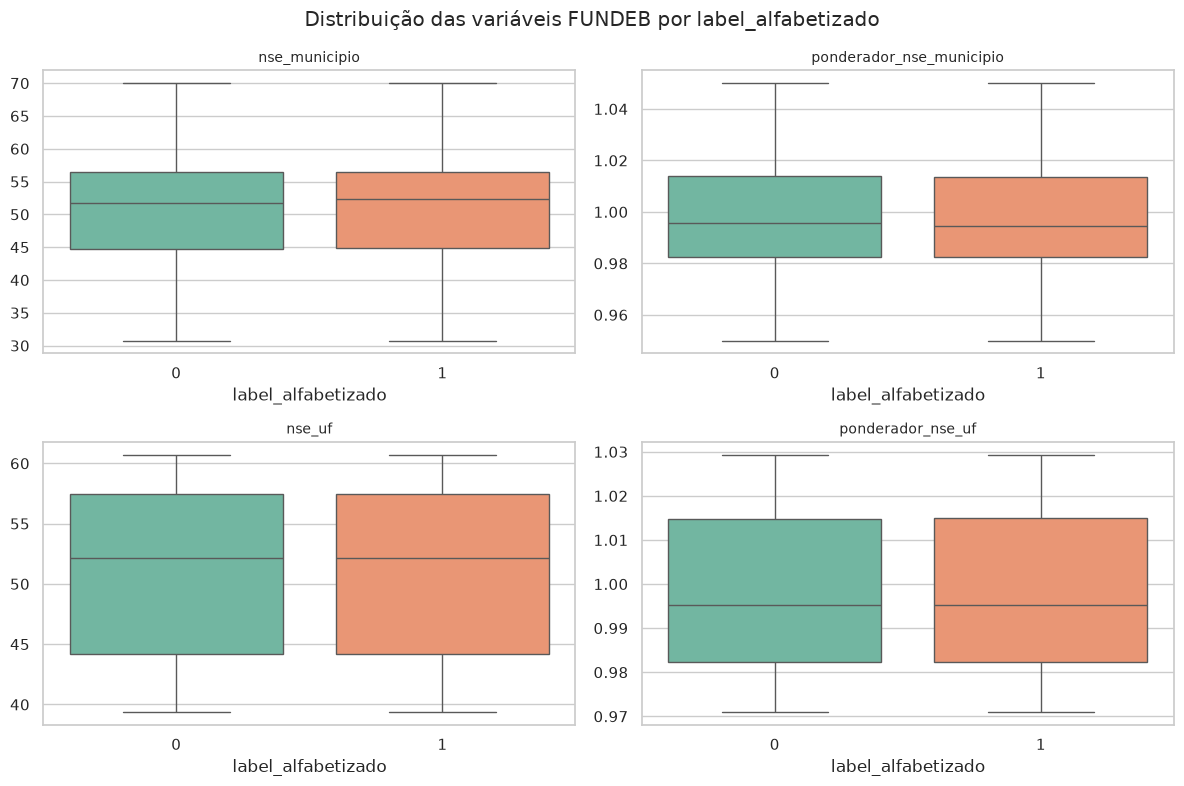

In [23]:
alvo = "label_alfabetizado"
df_plot = df.dropna(subset=[alvo])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, colunas_fundeb):
    sns.boxplot(data=df_plot, x=alvo, y=col, ax=ax, palette="Set2")
    ax.set_title(col.removeprefix("ctx_fundeb_"), fontsize=10)
    ax.set_xlabel(alvo)
    ax.set_ylabel("")

fig.suptitle("Distribuição das variáveis FUNDEB por label_alfabetizado")
plt.tight_layout()
plt.show()